In [ ]:
import sys

sys.path.append("..")

from utils.orientation_map import *
from utils.generation import *
from utils.filters import *
from utils.density_map import *

import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
def select_and_merge_density_maps(width, height):
    freq1 = load_random_density_map()
    freq2 = load_random_density_map()

    # Possibly load a third map
    flag_3 = rand() > 0.5
    freq3 = load_random_density_map() if flag_3 else None

    # Merge maps
    if flag_3:
        freq = (freq1 + freq2 + freq3) / 3 / 255.0
    else:
        freq = (freq1 + freq2) / 2 / 255.0

    # Resize to target dimensions, normalize to [0, 1]
    f_den = cv2.resize(freq, (width, height), interpolation=cv2.INTER_LINEAR)
    f_den = (f_den - np.min(f_den)) / (np.max(f_den) - np.min(f_den))

    return f_den

In [ ]:
singularity_type = 1

width=256
height=256

core_positions, delta_positions, arch_fact1, arch_fact2, k_arch = init_para_canonical(
    H=height, W=width, singularity_type=singularity_type
)
g_cap = set_param_canonical(singularity_type)

o_map = OrientationMap(
    width,
    height,
    singularity_type,
    delta_positions,
    core_positions,
    g_cap,
    arch_fact1,
    arch_fact2,
    k_arch,
)

orientation_map = o_map.getOrientationMap()

minutiae = []
target_count = 25
max_attempts = 1000
min_dist_sq = 16 ** 2  # 256. Comparing squared distances is faster!

attempts = 0
while len(minutiae) < target_count and attempts < max_attempts:
    attempts += 1
    y = random.randint(12, height - 12)
    x = random.randint(12, width - 12)
    
    # Assume the point is valid until proven otherwise
    is_valid = True
    
    for mx, my, _ in minutiae:
        # Calculate the squared Euclidean distance
        dist_sq = (x - mx)**2 + (y - my)**2
        
        if dist_sq < min_dist_sq:
            is_valid = False
            break  # It's too close to an existing point, abandon this (x, y)
            
    # If the point survived the checks against all existing minutiae, keep it
    if is_valid:
        minutiae.append((x, y, random.choice([-1, 1])))

cos_2_theta = torch.from_numpy(np.cos(2 * orientation_map)).float()
sin_2_theta = torch.from_numpy(np.sin(2 * orientation_map)).float()

freq_map = select_and_merge_density_maps(width, height)
freq_map_jitter = (
    (freq_map - np.min(freq_map)) / (np.max(freq_map) - np.min(freq_map)) * 0.05
)
base_freq = np.random.uniform(0.087, 0.133)
freq_map = base_freq + freq_map_jitter

In [ ]:
from utils.orientation_map import *
from utils.generation import *
from utils.filters import *
from utils.density_map import *
from utils.unwrapping import unwrap_with_smart_cuts
from arch_fingerprint_generator import reconstruct_continuous_phase

unwrapped_orientation = unwrap_with_smart_cuts(
    orientation_map,
    mask=np.ones_like(orientation_map, dtype=bool),
    singularities=[],
)

phase = reconstruct_continuous_phase(
    unwrapped_orientation=unwrapped_orientation,
    mask=np.ones_like(unwrapped_orientation, dtype=bool),
    block_size=1,
    freq_map=freq_map,
)

def add_spiral_phase(psi, points, polarities):
    # points: list of (y,x); polarities: +1 for termination, -1 for bifurcation (convention)
    H, W = psi.shape
    Y, X = np.mgrid[:H, :W]
    out = psi.copy()
    zero = np.zeros_like(psi)
    for (yy, xx), p in zip(points, polarities):
        zero += p * np.arctan2(Y - yy, X - xx)

    out += zero
    return out

spiral_phase_coords = []
spiral_phase_polarities = []

for x, y, p in minutiae:
    spiral_phase_coords.append((y, x))
    spiral_phase_polarities.append(p)

phase_with_spirals = add_spiral_phase(
    phase, spiral_phase_coords, spiral_phase_polarities
)
fprint = np.cos(phase_with_spirals)
original_fprint = np.cos(phase)

In [ ]:
def map_frequency_to_radius(freq_array, in_min=0.087, in_max=0.183, out_min=7, out_max=3):
    normalized = (freq_array - in_min) / (in_max - in_min)
    mapped = out_min + normalized * (out_max - out_min)
    clipped = np.clip(mapped, min(out_min, out_max), max(out_min, out_max))
    return np.round(clipped).astype(int)

def generate_minutiae_map(fingerprint_image, orientation_map, freq_map, minutiae_list, h, w, sigma_s):
    H_ending = np.zeros((h, w, 6))
    H_bifurcation = np.zeros((h, w, 6))
    max_freq = freq_map.max()
    min_freq = freq_map.min()
    Y, X = np.indices((h, w))
    
    for k in range(6):
        theta_k = k * np.pi / 3 
        
        for x, y, p in minutiae_list:
            dist_sq = (X - x)**2 + (Y - y)**2
            Cs = np.exp(-dist_sq / (2 * sigma_s**2))
        
            theta = orientation_map[y, x]
            radius = map_frequency_to_radius(freq_map[y, x], in_min=min_freq, in_max=max_freq, out_min=7, out_max=3)

            y_min = max(0, y - radius)
            y_max = min(h, y + radius + 1) # slicing exclusive at the end
            x_min = max(0, x - radius)
            x_max = min(w, x + radius + 1)

            neighborhood = fingerprint_image[y_min:y_max, x_min:x_max]
            total_pixels = neighborhood.size
            negative_count = np.sum(neighborhood < 0)
            
            is_ending = negative_count > (total_pixels / 2)

            theta = theta + np.pi / 2 if is_ending else theta - np.pi / 2
            theta = theta % (2 * np.pi)
            
            abs_diff = np.abs(theta - theta_k)
            if abs_diff <= np.pi:
                d_phi = abs_diff
            else:
                d_phi = 2 * np.pi - abs_diff
            
            Co = np.exp(-d_phi / (2 * sigma_s**2))
            contribution = Cs * Co
            if is_ending:
                H_ending[:, :, k] += contribution
            else:
                H_bifurcation[:, :, k] += contribution
           
    return H_ending, H_bifurcation

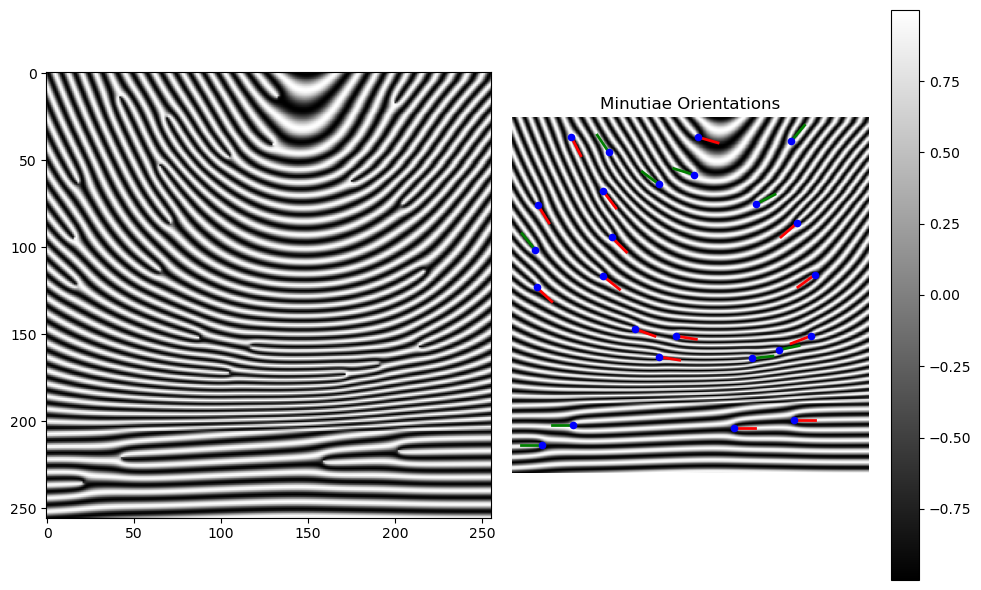

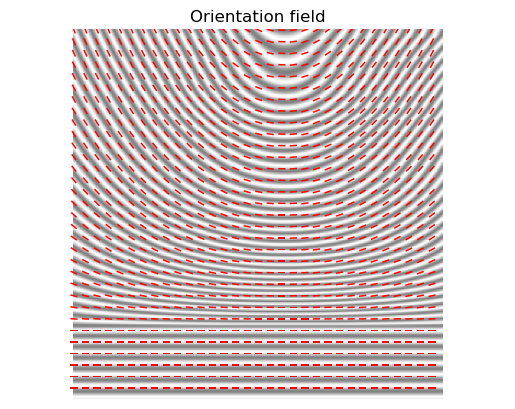

In [ ]:
def plot_minutiae_vectors(fingerprint_image, orientation_map, minutiae_list, freq_map, vector_length=15):
    # Set up the plot
    plt.imshow(fingerprint_image, cmap='gray')
    h, w = fingerprint_image.shape
    max_freq = freq_map.max()
    min_freq = freq_map.min()

    for x, y, polarity in minutiae_list:
        theta = orientation_map[y, x]
        radius = map_frequency_to_radius(freq_map[y, x], in_min=min_freq, in_max=max_freq, out_min=7, out_max=3)

        y_min = max(0, y - radius)
        y_max = min(h, y + radius + 1) # slicing exclusive at the end
        x_min = max(0, x - radius)
        x_max = min(w, x + radius + 1)

        # plot area defined by bounds
        # plt.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max, y_max, y_min], color='yellow', linewidth=1)
        
        neighborhood = fingerprint_image[y_min:y_max, x_min:x_max]
        total_pixels = neighborhood.size
        negative_count = np.sum(neighborhood < 0)
        
        is_ending = negative_count > (total_pixels / 2)

        theta = theta + np.pi / 2 if is_ending else theta - np.pi / 2
        theta = theta % (2 * np.pi)

        # plot type of minutiae
        x_end = x + vector_length * np.sin(theta)
        y_end = y - vector_length * np.cos(theta) 
        # plt.plot([x, x_end], [y, y_end], color='red' if is_ending else 'green', linewidth=2)
        
        # Plot the starting minutiae point (blue dot) to anchor the vector
        plt.scatter(x, y, color='red', s=20, zorder=3)

    plt.title("Minutiae Orientations")
    plt.axis('off') # Hides the axis ticks for a cleaner look
    plt.tight_layout()
    plt.show()


def quiver_plot(orientation_field, fingerprint_image=None):
    stride = 8
    height, width = orientation_field.shape[0], orientation_field.shape[1]
    # mgrid returns: 1st output (Y/Rows), 2nd output (X/Cols)
    ys, xs = np.mgrid[0:height:stride, 0:width:stride]

    U = np.cos(orientation_field[::stride, ::stride])
    V = np.sin(orientation_field[::stride, ::stride])


    if fingerprint_image is not None:
        plt.imshow(fingerprint_image, cmap='gray', alpha=0.3)
    plt.quiver(
        xs,  # X coordinates (Columns)
        ys,  # Y coordinates (Rows)
        U,
        V,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=0.2,  # Tweak this if arrows are too small/large
        width=0.003,
        headaxislength=0,
        headlength=0,
        headwidth=0,
        pivot="mid",  # Anchors the arrow at the center of the pixel
    )

    plt.axis("equal")  # Ensures pixels are square
    plt.axis("off")

    # save figure
    plt.savefig("orientation_field_quiver.png", bbox_inches="tight", pad_inches=0)

plt.figure(figsize=(13, 4))
plt.subplot(1, 2, 1)
plt.imshow(fprint, cmap='gray')
plt.axis('off')
plt.subplot(122)
plot_minutiae_vectors(fprint, orientation_map, minutiae, freq_map)
plt.subplot(133)
quiver_plot(orientation_map, fingerprint_image=original_fprint)

In [ ]:
from utils.orientation_map import *
from utils.generation import *
from utils.filters import *
from utils.density_map import *
from utils.unwrapping import unwrap_with_smart_cuts
from arch_fingerprint_generator import reconstruct_continuous_phase

unwrapped_orientation = unwrap_with_smart_cuts(
    orientation_map,
    mask=np.ones_like(orientation_map, dtype=bool),
    singularities=[],
)

phase = reconstruct_continuous_phase(
    unwrapped_orientation=unwrapped_orientation,
    mask=np.ones_like(unwrapped_orientation, dtype=bool),
    block_size=1,
    freq_map=freq_map,
)

def add_spiral_phase(psi, points, polarities):
    # points: list of (y,x); polarities: +1 for termination, -1 for bifurcation (convention)
    H, W = psi.shape
    Y, X = np.mgrid[:H, :W]
    out = psi.copy()
    zero = np.zeros_like(psi)
    for (yy, xx), p in zip(points, polarities):
        zero += p * np.arctan2(Y - yy, X - xx)

    out += zero
    return out

spiral_phase_coords = []
spiral_phase_polarities = []

for x, y, p in minutiae:
    spiral_phase_coords.append((y, x))
    spiral_phase_polarities.append(p)

phase_with_spirals = add_spiral_phase(
    phase, spiral_phase_coords, spiral_phase_polarities
)
fprint = np.cos(phase_with_spirals)
original_fprint = np.cos(phase)

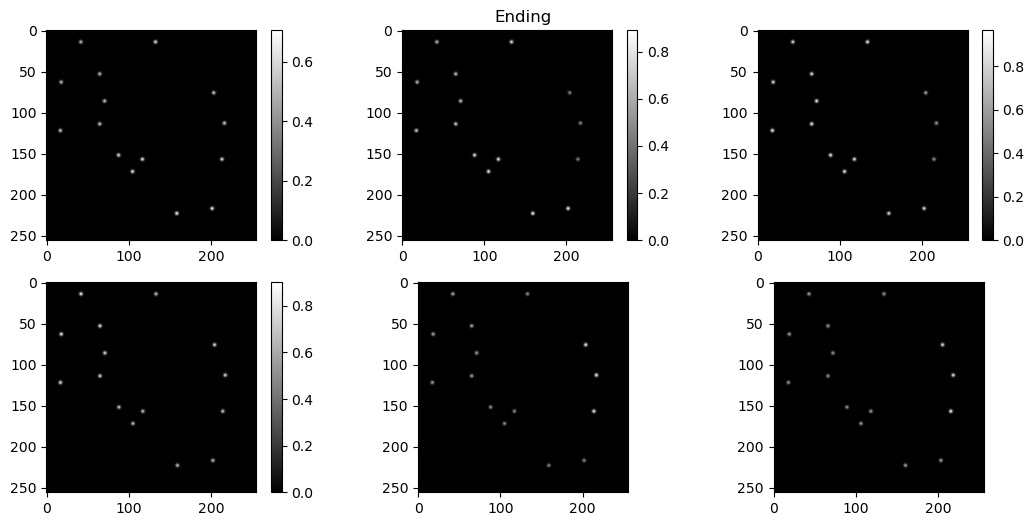

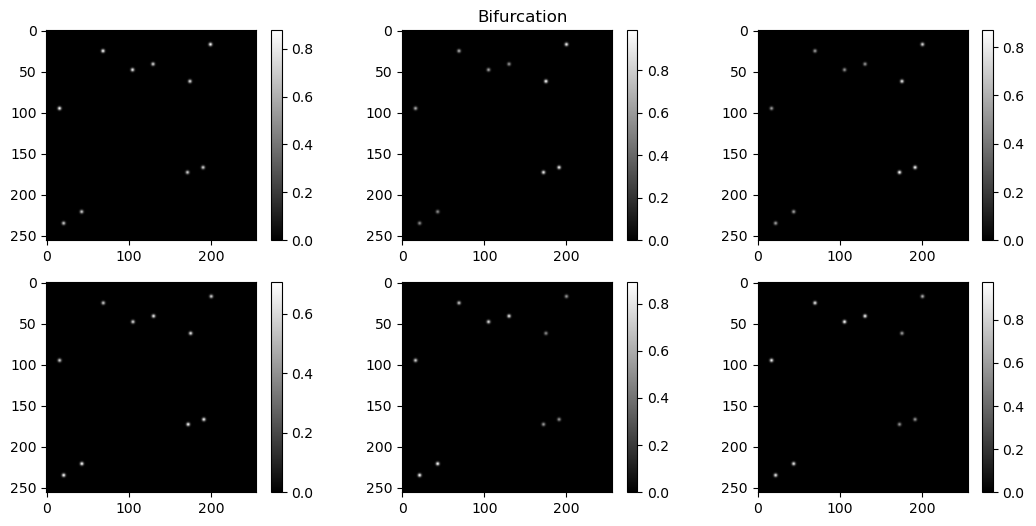

In [ ]:
H_ending, H_bifurcation = generate_minutiae_map(fprint, orientation_map, freq_map, minutiae, height, width, sigma_s=1.5)
# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 6))
plt.axis("off")
plt.title("Ending")
plt.subplot(2, 3, 1)
plt.imshow(H_ending[:, :, 0], cmap="gray")
plt.colorbar()
plt.subplot(2, 3, 2)
plt.imshow(H_ending[:, :, 1], cmap="gray")
plt.colorbar()

plt.subplot(2, 3, 3)
plt.imshow(H_ending[:, :, 2], cmap="gray")
plt.colorbar()

plt.subplot(2, 3, 4)
plt.imshow(H_ending[:, :, 3], cmap="gray")
plt.colorbar()

plt.subplot(2, 3, 5)
plt.imshow(H_ending[:, :, 4], cmap="gray")
plt.subplot(2, 3, 6)
plt.imshow(H_ending[:, :, 5], cmap="gray")
plt.show()

plt.figure(figsize=(13, 6))
plt.axis("off")
plt.title("Bifurcation")

plt.subplot(2, 3, 1)
plt.imshow(H_bifurcation[:, :, 0], cmap="gray")
plt.colorbar()

plt.subplot(2, 3, 2)
plt.imshow(H_bifurcation[:, :, 1], cmap="gray")
plt.colorbar()

plt.subplot(2, 3, 3)
plt.imshow(H_bifurcation[:, :, 2], cmap="gray")
plt.colorbar()

plt.subplot(2, 3, 4)
plt.imshow(H_bifurcation[:, :, 3], cmap="gray")
plt.colorbar()

plt.subplot(2, 3, 5)
plt.imshow(H_bifurcation[:, :, 4], cmap="gray")
plt.colorbar()

plt.subplot(2, 3, 6)
plt.imshow(H_bifurcation[:, :, 5], cmap="gray")
plt.colorbar()

plt.show()

In [ ]:
# save figures
plt.imsave("viz_freq_maps.png", freq_map, cmap="gray")
plt.imsave("viz")